## **P1 - Audit of dataset**  
This submission contains a runnable notebook demonstrating the audit of our selected data set for the course IDIG4120 *Digital Information Processing*.

### Task Description
*Describe how your data is actually represented, and test the assumptions everything later depends on. The
baseline you fix here is what P2 measures its compression against.*  
Format, array shape, data type, units, range and byte size.
 - [ ] Sampling rate or spacing. Say so where the concept does not apply, or is unknown.
 - [ ] One time or spatial view and one frequency view, both with labelled axes.
 - [ ] One transform or filtering experiment, with the prediction you made before running it.
 - [ ] One resampling or quantisation experiment that finds an artefact or a limitation.
 - [ ] A reproducible loader, and the baseline representation P2 will be measured against.
 - [ ] One Visual Informatics concern and one implementation, integrity or security concern that meet in this dataset.
 - [ ] Who did what, and the generative-AI declaration.

### 1.) **Pre audit dataset details:** (Repeat of P0)
 
 - **Name**: UrbanSound8k  
 - **Stable source**: Kaggle Link: https://www.kaggle.com/datasets/chrisfilo/urbansound8k  
    - **Retrieval date**: August 25th, 2026  
 - **Licence**: CC BY-NC 4.0 on Kaggle; non-commercial  
 - **Scale**: 8,732 clips at <=4 seconds each with 10 different labels split into 10 folds  
    - **Classes/labels**: air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, and street_music  
 - **File formats**: 8732 .wav files and 1 .csv with metadata and labels  
 - **Representation**: Waveform data, various configurations (source: https://audeering.github.io/audbcards/audb-public/urbansound8k.html)  
    - **Bitdepths**: 4,8,16,24,32  
    - **Channels**: 1,2  
    - **Sampling** rate: 8000, 11024, 11025, 16000, 22050, 24000, 32000, 44100, 48000, 96000, 192000  
 - **Quality risks**: Varying recording quality  
 - **Integrity risks**: Corrupt/malformed files, faulty/incorrect headers (Shouldn't be a problem given other people having used the dataset)  
 - **Security risks**: N/A  


In [25]:
#Imports
from __future__ import annotations
import csv
from collections.abc import Callable
from dataclasses import dataclass
from enum import auto, StrEnum
import io
from logging import getLogger
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from scipy.io import wavfile
import soundfile as sf


In [26]:
#Types and constants

@dataclass
class Metadata:
    file_name: str
    bit_depth: int
    dtype: str
    subtype: str #WAV subtype
    channel_count: int
    label: CLASSES
    byte_size: int
    frame_count: int
    sample_rate: int
    amplitude_min: int
    amplitude_max: int


logger = getLogger(__name__)

DATASET_NAME: str = "UrbanSound8k"
DATASET_PATH: Path = Path.cwd().parent / "archive"
GLOB: str = "fold*/*.wav"

FREQUENCY_BINS: int = 512
MAX_FREQUENCY_HZ: float = 22050.0

LICENSE_STRING = "CC BY-NC 4.0"
SOURCE: str = "https://www.kaggle.com/datasets/chrisfilo/urbansound8k"



#Expected values (based on P0)

#File counts
NUM_FILES: int = 8733
NUM_WAV: int = 8732
NUM_CSV: int = 1


#Classes (specified in metadata.csv)
class CLASSES(StrEnum):
    AC = "air_conditioner"
    CARHORN = "car_horn"
    CHILDREN = "children_playing"
    DOG = "dog_bark"
    DRILL = "drilling"
    ENGINE = "engine_idling"
    GUN = "gun_shot"
    JACK = "jackhammer"
    SIREN = "siren"
    STREETMUSIC = "street_music"
    UNKNOWN = auto()

#Representation
BITDEPTHS: set[int] = {4, 8, 16, 24, 32}
CHANNELS: set[int] = {1, 2}
SAMPLING_RATES: set[int] = {8000, 11024, 11025, 16000, 22050, 24000, 32000, 44100, 48000, 96000, 192000}


AMPLITUDE_MEANING: str = "Raw sample values decoded from each file's native WAV subtype (int/float PCM or compressed), dimensionless, no physical unit calibration provided by the dataset"



### 2.) Dataset loader and audit

Loads the dataset, then audits it: file/format statistics and distributions, and a frequency domain across every file matched by `GLOB`

{'amplitude_max': 2147483392,
 'amplitude_min': -2147483648,
 'amplitude_units': "Raw sample values decoded from each file's native WAV "
                    'subtype (int/float PCM or compressed), dimensionless, no '
                    'physical unit calibration provided by the dataset',
 'average_bit_depth': 21.314704535043518,
 'average_byte_size': 935620.240494732,
 'average_frame_count': 173863.51946862118,
 'average_playtime': 3.607521829246339,
 'average_sample_rate': 48456.97927164452,
 'filecount': 8732,
 'single_channel_files': 739,
 'total_byte_size': 8169835940,
 'total_playtime': 31500.880612979032,
 'valid': 8732}
Bit Depth Counts
  16: 5767
  32: 2922
  8: 43
Data Type Counts
  float32: 169
  int16: 5767
  int32: 2753
  uint8: 43
Subtype Counts
  FLOAT: 169
  IMA_ADPCM: 1
  MS_ADPCM: 8
  PCM_16: 5758
  PCM_24: 2753
  PCM_U8: 43


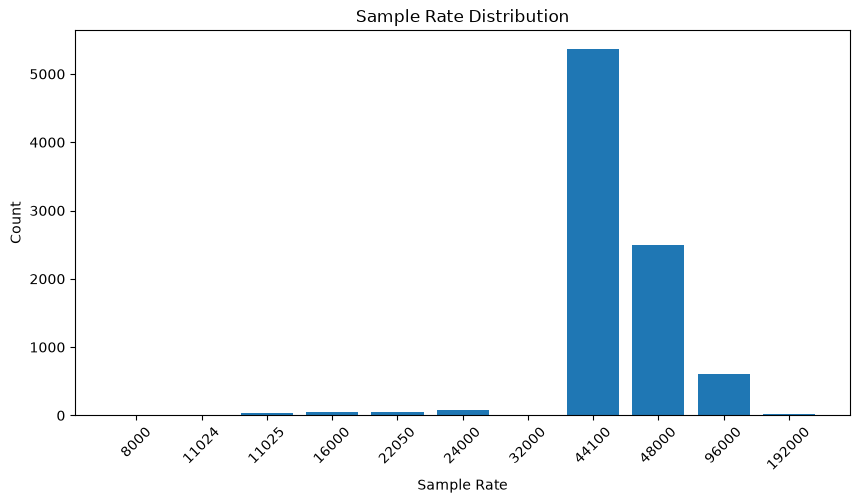

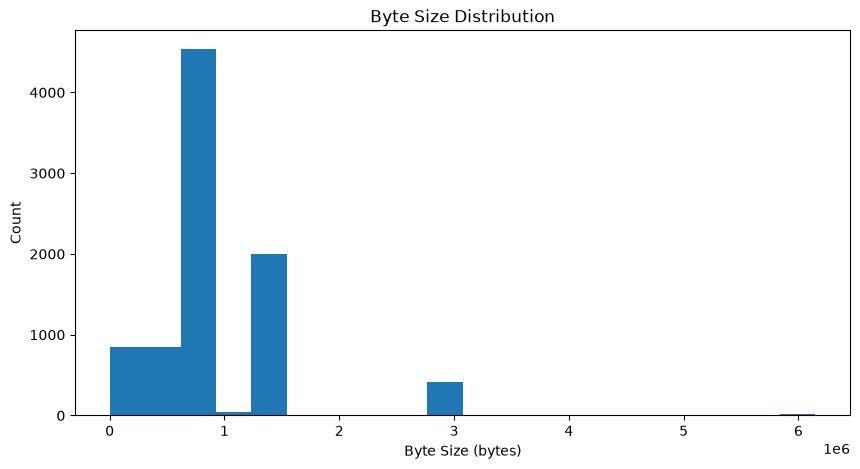

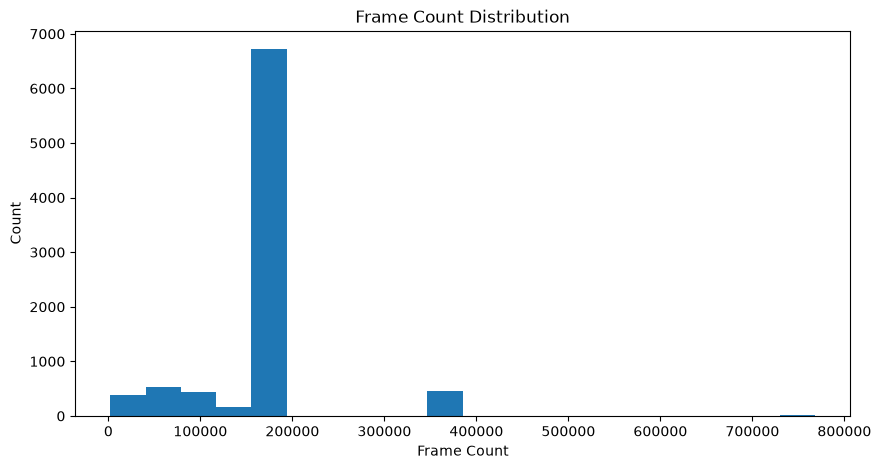

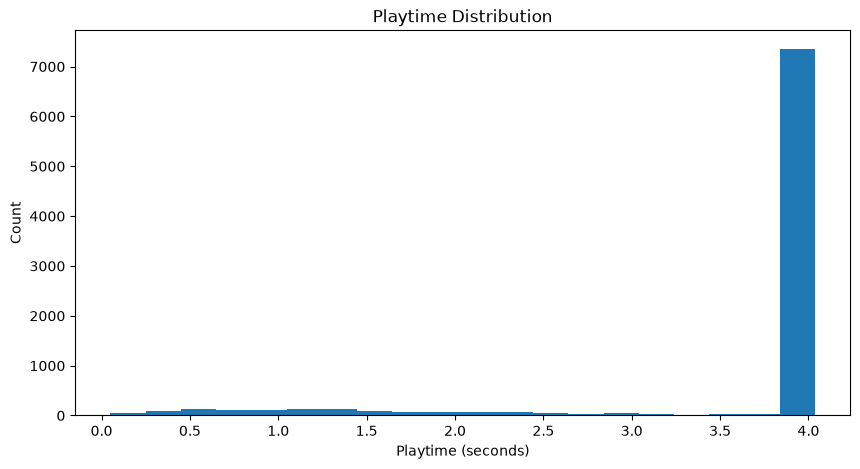

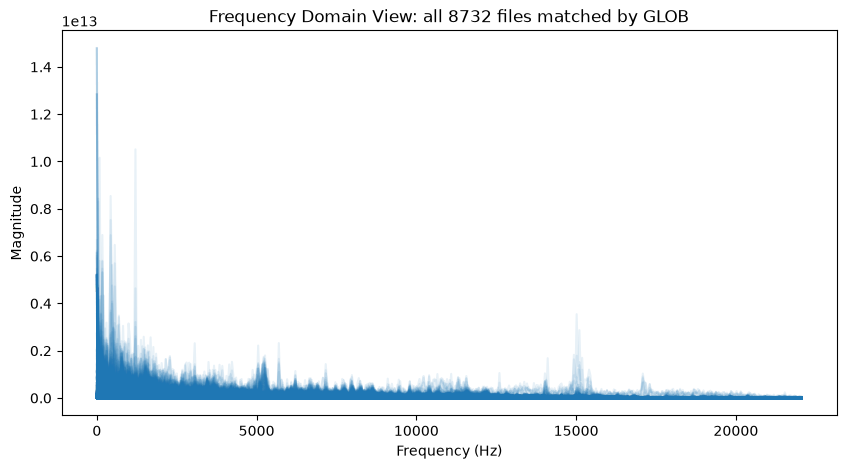

In [27]:
def _log_and_raise(message: str, exception: type[Exception] | Exception) -> None:
    logger.error(f"{message} {exception}")
    if isinstance(exception, type):
        raise exception(message)
    raise exception

def load_dataset(path: Path, transform: Callable[[np.ndarray], np.ndarray] | None = None, visualize: bool = False) -> dict:
    '''
        Loads and audits the dataset located at path.

        Args:
            path: Absolute path to the folder containing the dataset
            transform: Optional per-file transform
            visualize: Whether the audit should also plot its results

        Returns:
            The audit statistics; audio samples are not retained per file to avoid using too much memory
    '''
    logger.info(f"Loading dataset from {path}")
    dataset: list[Metadata] = []
    spectra: list[np.ndarray] = []

    if not path.exists():
        _log_and_raise(f"Dataset path {path} not found", FileNotFoundError)

    if not path.is_dir():
        _log_and_raise(f"Dataset path {path} is not a directory", TypeError)

    metadata = load_csv(path / "UrbanSound8K.csv")

    for file in path.glob(GLOB):
        try:
            data, file_metadata = load_wav(file, metadata, transform)
            channel = data[:, 0] if data.ndim > 1 else data

            spectra.append(compute_magnitude_spectrum(channel, file_metadata.sample_rate, FREQUENCY_BINS, MAX_FREQUENCY_HZ))
            dataset.append(file_metadata)

            #if not validate_wav(dataset[-1]): #TODO: not
            #    logger.warning(f"Unexpected wav metadata for file {file}")
        except Exception as e:
            logger.warning(f"Skipping {file}, failed to load: {e}")

    return audit_dataset(dataset, spectra, visualize)



def load_wav(path: Path, dataset_: list[dict], transform: Callable[[np.ndarray], np.ndarray] | None = None) -> tuple[np.ndarray, Metadata]:
    '''
        Loads and validates the contents of a single .wav file.

        Args:
            path: Absolute path to the .wav file.
            transform: Optional transform applied to the wav files

        Returns:
            (ndarray, Metadata) a numpy array with wav data and metadata
        
        Raises:
            FileNotFoundError
            RuntimeError
            TypeError

    '''
    if not path.exists():
        _log_and_raise(f"File {path} not found", FileNotFoundError)

    if not path.is_file():
        _log_and_raise(f"File {path} is not a file", TypeError)

    if path.suffix.lower() != ".wav":
        _log_and_raise(f"File {path} is not a .wav file", TypeError) #TODO: Consider changing as .wav extension in name is a windows specific limitation

    try:
        samplerate, data = _read_wav(path)
        if transform is not None:
            data = transform(data)
        metadata = get_metadata(path, samplerate, data)
        return data, metadata
    except Exception as e:
        _log_and_raise(f"Failed to load wav file {path}", e)



def _read_wav(path: Path) -> tuple[int, np.ndarray]:
    '''
        Computes and returns metadata from wav file contents.

        Args:
            path: Absolute path to the .wav file.

        Returns:
            (samplerate, ndarray) the sample rate and decoded sample data
    '''
    try:
        return wavfile.read(path)
    except (ValueError, NotImplementedError) as scipy_error:
        try:
            data, samplerate = sf.read(path, dtype="int16")
            return samplerate, data
        except Exception as soundfile_error:
            raise RuntimeError(f"Could not decode {path}: scipy={scipy_error}, soundfile={soundfile_error}") from soundfile_error


def _wav_byte_size(samplerate: int, data: np.ndarray) -> int:
    '''
        Encodes samples as a WAV in memory to measure the resulting file size.

        Args:
            samplerate: Sample rate of the clip
            data: Sample data to encode

        Returns:
            Size of the encoded WAV in bytes, headers included
    '''
    buffer = io.BytesIO()
    wavfile.write(buffer, samplerate, data)
    return buffer.getbuffer().nbytes


def get_metadata(path: Path, samplerate: int, data: np.ndarray) -> Metadata:
    '''
        Computes and returns metadata from already-read wav file contents.

        Args:
            path: Absolute path to the .wav file.
            samplerate: Sample rate of the wav file.
            data: Decoded sample data of the wav file.

        Returns:
            Metadata class containing metadata extracted from the wav file
    '''
    return Metadata(
        file_name = path.name,
        bit_depth = data.dtype.itemsize * 8,
        dtype = str(data.dtype),
        subtype = sf.info(path).subtype,
        channel_count = data.shape[1] if data.ndim > 1 else 1,
        label = CLASSES.UNKNOWN, #TODO: add look up in csv for class/label
        byte_size = _wav_byte_size(samplerate, data),
        frame_count = data.shape[0],
        sample_rate = samplerate,
        amplitude_min = int(np.min(data)),
        amplitude_max = int(np.max(data))
    )

def load_csv(path: Path) -> list[dict]:
    '''
        Loads and validates the contents of a CSV file.

        Args:
            path: Absolute path to the CSV file.

        Returns:
            List of dictionaries containing CSV data.

        Raises:
            FileNotFoundError
            RuntimeError
            TypeError
    '''
    if not path.exists():
        _log_and_raise(f"File {path} not found", FileNotFoundError)

    if not path.is_file():
        _log_and_raise(f"File {path} is not a file", TypeError)

    if path.suffix.lower() != ".csv":
        _log_and_raise(f"File {path} is not a .csv file", TypeError)

    try:
        with open(path, newline='') as csvfile:
            reader = csv.DictReader(csvfile)
            return [row for row in reader]
    except Exception as e:
        _log_and_raise(f"Failed to read CSV file {path}", e)


def validate_wav(metadata: Metadata) -> bool:
    '''
        Validates the metadata of a wav file.

        Args:
            metadata: Metadata object containing wav file information.

        Returns:
            True if the wav file metadata is valid, False otherwise.
    '''
    issue = False
    logger.info(f"Validating wav metadata for file: {metadata.file_name}")

    if metadata.bit_depth not in BITDEPTHS:
        logger.warning(f"\tUnexpected bit depth: {metadata.bit_depth}")
        issue = True
    if metadata.channel_count not in CHANNELS:
        logger.warning(f"\tUnexpected channel count: {metadata.channel_count}")
        issue = True
    if metadata.frame_count <= 0:
        logger.warning(f"\tInvalid frame count: {metadata.frame_count}")
        issue = True
    if metadata.sample_rate not in SAMPLING_RATES:
        logger.warning(f"\tInvalid sample rate: {metadata.sample_rate}")
        issue = True
    return not issue


def audit_dataset(dataset: list[Metadata], spectra: list[np.ndarray], visualize: bool = False) -> dict:
    '''
        Computes audit statistics for the given metadata.

        Args:
            dataset: Metadata records to audit
            spectra: Magnitude spectra, carried in the statistics for the frequency view
            visualize: Whether to also plot the statistics

        Returns:
            The audit statistics
    '''
    statistics = {
        "filecount": 0,
        "valid": 0,
        "bitdepth_counts":dict(),
        "average_bit_depth": 0,

        "dtype_counts": dict(),
        "subtype_counts": dict(),

        "sample_rate_counts": dict(),
        "average_sample_rate": 0,

        "single_channel_files": 0,

        "byte_sizes": [],
        "average_byte_size": 0,
        "total_byte_size": 0,
        
        "frame_counts": [],
        "average_frame_count": 0,
        "playtimes": [],
        "average_playtime": 0.0,
        "total_playtime": 0.0,

        "amplitude_min": None,
        "amplitude_max": None,
        "amplitude_units": AMPLITUDE_MEANING,

        "spectra": spectra,
        
    }
    for metadata in dataset:
        statistics["filecount"] += 1
        #if validate_wav(metadata):
        statistics["valid"] += 1 #TODO: gate
        if statistics["bitdepth_counts"].get(metadata.bit_depth) is None:
            statistics["bitdepth_counts"][metadata.bit_depth] = 0
        statistics["bitdepth_counts"][metadata.bit_depth] = statistics["bitdepth_counts"].get(metadata.bit_depth, 0) + 1
        if statistics["dtype_counts"].get(metadata.dtype) is None:
            statistics["dtype_counts"][metadata.dtype] = 0
        statistics["dtype_counts"][metadata.dtype] += 1
        if statistics["subtype_counts"].get(metadata.subtype) is None:
            statistics["subtype_counts"][metadata.subtype] = 0
        statistics["subtype_counts"][metadata.subtype] += 1
        if statistics["sample_rate_counts"].get(metadata.sample_rate) is None:
            statistics["sample_rate_counts"][metadata.sample_rate] = 0
        statistics["sample_rate_counts"][metadata.sample_rate] = statistics["sample_rate_counts"].get(metadata.sample_rate, 0) + 1
        if metadata.channel_count == 1:
            statistics["single_channel_files"] += 1
        statistics["byte_sizes"].append(metadata.byte_size)
        statistics["total_byte_size"] += metadata.byte_size
        statistics["frame_counts"].append(metadata.frame_count)
        playtime = metadata.frame_count / metadata.sample_rate
        statistics["playtimes"].append(playtime)
        statistics["total_playtime"] += playtime
        if statistics["amplitude_min"] is None or metadata.amplitude_min < statistics["amplitude_min"]:
            statistics["amplitude_min"] = metadata.amplitude_min
        if statistics["amplitude_max"] is None or metadata.amplitude_max > statistics["amplitude_max"]:
            statistics["amplitude_max"] = metadata.amplitude_max

    statistics["average_bit_depth"] = sum([k * v for k, v in statistics["bitdepth_counts"].items()]) / statistics["filecount"] if statistics["filecount"] > 0 else 0
    statistics["average_sample_rate"] = sum([k * v for k, v in statistics["sample_rate_counts"].items()]) / statistics["filecount"] if statistics["filecount"] > 0 else 0
    statistics["average_byte_size"] = statistics["total_byte_size"] / statistics["filecount"] if statistics["filecount"] > 0 else 0
    statistics["average_frame_count"] = sum(statistics["frame_counts"]) / statistics["filecount"] if statistics["filecount"] > 0 else 0
    statistics["average_playtime"] = statistics["total_playtime"] / statistics["filecount"] if statistics["filecount"] > 0 else 0

    if visualize:
        visualize_audit(statistics)
    return statistics

def _plot_counts(counts: dict, title: str, xlabel: str, rotation: int = 0) -> None:
    labels = sorted(counts.keys())
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(labels)), [counts[k] for k in labels])
    plt.xticks(range(len(labels)), labels, rotation=rotation)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()


def _print_table(counts: dict, title: str) -> None:
    print(title)
    for key in sorted(counts.keys(), key=str):
        print(f"  {key}: {counts[key]}")


def _plot_histogram(values: list, title: str, xlabel: str) -> None:
    plt.figure(figsize=(10, 5))
    plt.hist(sorted(values), bins=20)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()


def visualize_audit(statistics: dict) -> None:
    import pprint
    excluded = ("byte_sizes", "frame_counts", "playtimes", "bitdepth_counts", "dtype_counts", "subtype_counts", "sample_rate_counts", "spectra")
    pprint.pprint({k: v for k, v in statistics.items() if k not in excluded})

    _print_table(statistics["bitdepth_counts"], "Bit Depth Counts")
    _print_table(statistics["dtype_counts"], "Data Type Counts")
    _print_table(statistics["subtype_counts"], "Subtype Counts")
    _plot_counts(statistics["sample_rate_counts"], "Sample Rate Distribution", "Sample Rate", rotation=45)
    _plot_histogram(statistics["byte_sizes"], "Byte Size Distribution", "Byte Size (bytes)")
    _plot_histogram(statistics["frame_counts"], "Frame Count Distribution", "Frame Count")
    _plot_histogram(statistics["playtimes"], "Playtime Distribution", "Playtime (seconds)")

    if statistics["spectra"]:
        plot_frequency_view_all_files(statistics["spectra"])


def compute_magnitude_spectrum(data: np.ndarray, samplerate: int, n_bins: int, max_freq: float) -> np.ndarray:
    '''
        Computes a magnitude spectrum for the given audio data.

        Args:
            data: Decoded single-channel sample data
            samplerate: Sample rate of the clip
            n_bins: Number of bins
            max_freq: Max frequency in Hz

        Returns:
            ndarray of length n_bins with magnitude values
    '''
    spectrum = np.abs(np.fft.rfft(data))
    freqs = np.fft.rfftfreq(data.shape[0], d=1 / samplerate)
    common_freqs = np.linspace(0, max_freq, n_bins)
    return np.interp(common_freqs, freqs, spectrum, left=0, right=0)


def plot_frequency_view_all_files(spectra: list[np.ndarray], n_bins: int = FREQUENCY_BINS, max_freq: float = MAX_FREQUENCY_HZ) -> None:
    '''
        Display frequency spectra for all files

        Args:
            spectra: Magnitude spectra
            n_bins: Number of frequency bins
            max_freq: Maximum frequency in Hz
    '''
    common_freqs = np.linspace(0, max_freq, n_bins)

    plt.figure(figsize=(10, 5))
    for spectrum in spectra:
        plt.plot(common_freqs, spectrum, alpha=0.1, color="tab:blue")

    plt.title(f"Frequency Domain View: all {len(spectra)} files matched by GLOB")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.show()


baseline_statistics = load_dataset(DATASET_PATH)
visualize_audit(baseline_statistics)


### 3.) Quantisation experiment

**Expectation:** The loader is run again, this time with a transform that forces every file onto the int16 range regardless of its native bit depth. The resulting audit can be compared against the audit in section 2). Bit depths already at or below 16-bit should show no real change (false precision), while 24/32-bit or float files should show real amplitude range and byte size changes.

{'amplitude_max': 32767,
 'amplitude_min': -32768,
 'amplitude_units': "Raw sample values decoded from each file's native WAV "
                    'subtype (int/float PCM or compressed), dimensionless, no '
                    'physical unit calibration provided by the dataset',
 'average_bit_depth': 16.0,
 'average_byte_size': 670305.7333944114,
 'average_frame_count': 173863.51946862118,
 'average_playtime': 3.607521829246339,
 'average_sample_rate': 48456.97927164452,
 'filecount': 8732,
 'single_channel_files': 739,
 'total_byte_size': 5853109664,
 'total_playtime': 31500.880612979032,
 'valid': 8732}
Bit Depth Counts
  16: 8732
Data Type Counts
  int16: 8732
Subtype Counts
  FLOAT: 169
  IMA_ADPCM: 1
  MS_ADPCM: 8
  PCM_16: 5758
  PCM_24: 2753
  PCM_U8: 43


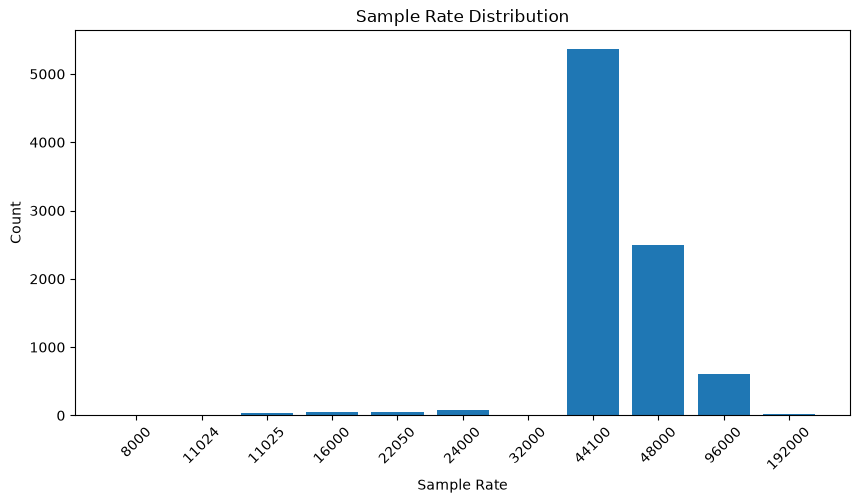

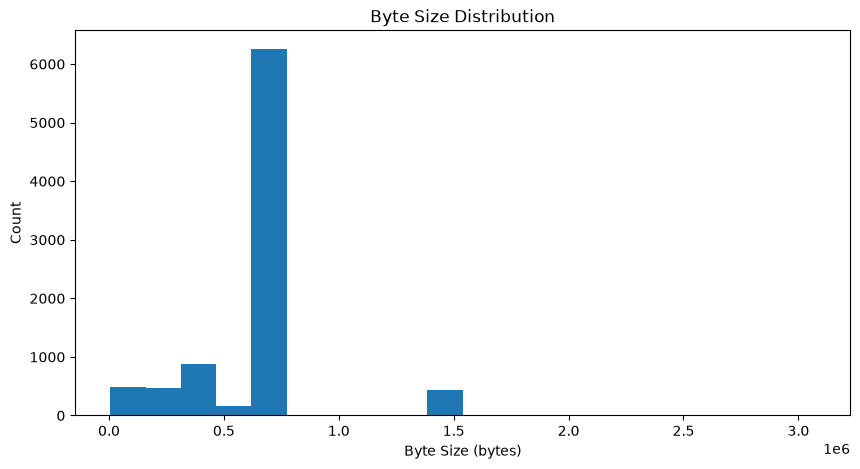

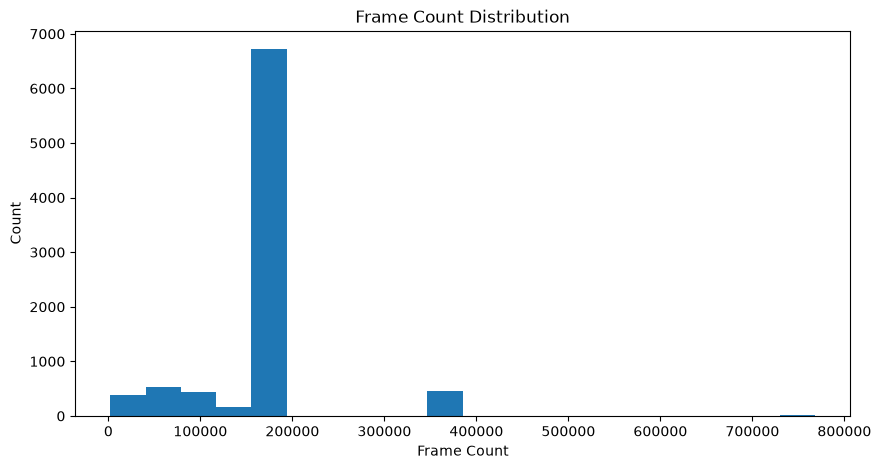

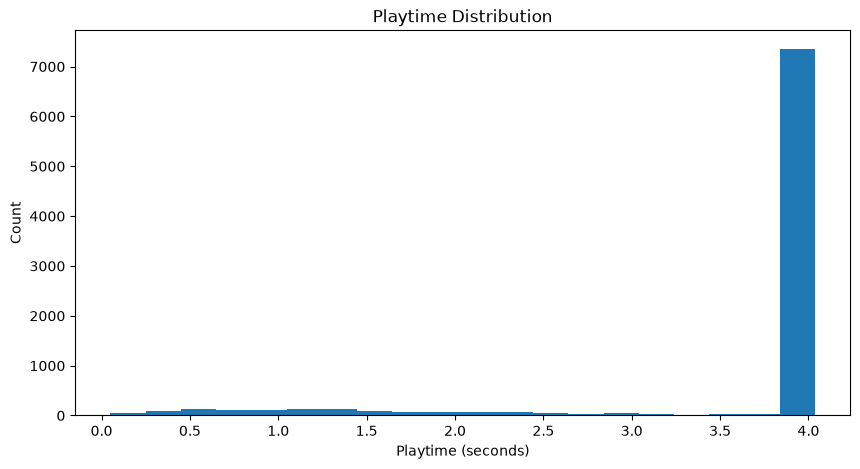

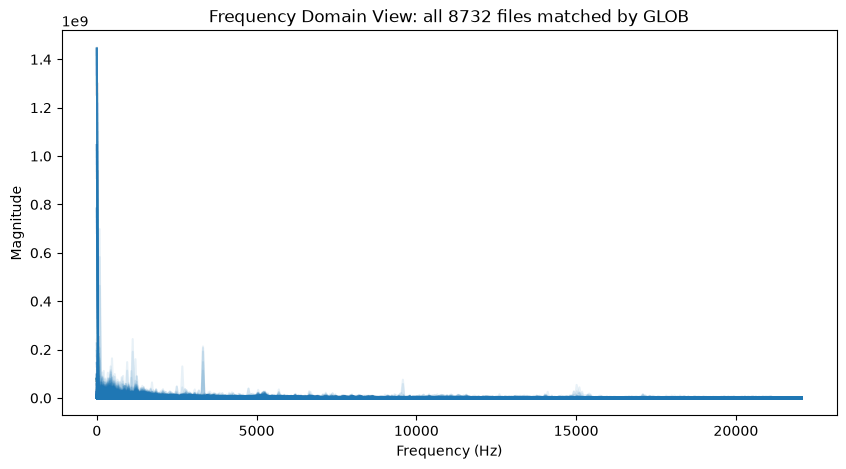

In [28]:
def quantize_to_int16(data: np.ndarray) -> np.ndarray:
    '''
        Rescales decoded samples to int16

        Args:
            data: Decoded single-channel sample data, any numeric dtype

        Returns:
            np.ndarray of int16 samples
    '''
    MAX_INT16 = 32767
    MIN_INT16 = -32768

    if np.issubdtype(data.dtype, np.floating):
        return np.clip(data * MAX_INT16, MIN_INT16, MAX_INT16).astype(np.int16)
    if data.dtype == np.int16:
        return data
    info = np.iinfo(data.dtype)
    scale = MAX_INT16 / max(abs(int(info.min)), int(info.max))
    return np.clip(data.astype(np.float64) * scale, MIN_INT16, MAX_INT16).astype(np.int16)


quantized_statistics = load_dataset(DATASET_PATH, transform=quantize_to_int16)
visualize_audit(quantized_statistics)


### 4.) 

**Expectation:** Through this expiriminet we will test how much spectral energy remain after progressively removing high frequencies. We will use a low-pass cutoff vs retained energy-expiriment by applying several Fourier-domain low-pass filters. 


In [13]:
from io import BytesIO

# Thresholds are fractions of the strongest Fourier magnitude in each channel.
# 0.001 means coefficients below 0.1% of that channel's strongest component are removed.
FOURIER_THRESHOLDS = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]


def prune_fourier_components(signal: np.ndarray, threshold_ratio: float):
    """Remove weak rFFT coefficients and return a sparse representation."""
    spectrum = np.fft.rfft(signal, axis=0)
    magnitude = np.abs(spectrum)

    if spectrum.ndim == 1:
        strongest = magnitude.max()
    else:
        # Apply the same relative rule independently to each channel.
        strongest = magnitude.max(axis=0, keepdims=True)

    cutoff = threshold_ratio * strongest
    keep_mask = magnitude >= cutoff

    flat_mask = keep_mask.reshape(-1)
    indices = np.flatnonzero(flat_mask).astype(np.uint32)
    values = spectrum.reshape(-1)[flat_mask].astype(np.complex64)

    return indices, values, spectrum.shape, keep_mask


def sparse_fourier_file_size(
    indices: np.ndarray,
    values: np.ndarray,
    spectrum_shape: tuple[int, ...],
    n_samples: int,
    sample_rate: int,
) -> int:
    """Serialize the sparse coefficients in memory and return the resulting byte size."""
    buffer = BytesIO()
    np.savez_compressed(
        buffer,
        indices=indices,
        values=values,
        spectrum_shape=np.asarray(spectrum_shape, dtype=np.int32),
        n_samples=np.asarray([n_samples], dtype=np.int32),
        sample_rate=np.asarray([sample_rate], dtype=np.int32),
    )
    return buffer.tell()


def reconstruct_from_sparse_fourier(
    indices: np.ndarray,
    values: np.ndarray,
    spectrum_shape: tuple[int, ...],
    n_samples: int,
) -> np.ndarray:
    """Reconstruct a waveform from the retained sparse Fourier coefficients."""
    sparse_spectrum = np.zeros(np.prod(spectrum_shape), dtype=np.complex64)
    sparse_spectrum[indices] = values
    sparse_spectrum = sparse_spectrum.reshape(spectrum_shape)

    return np.fft.irfft(
        sparse_spectrum,
        n=n_samples,
        axis=0
    ).astype(np.float32)


def rmse(reference: np.ndarray, reconstructed: np.ndarray) -> float:
    return float(
        np.sqrt(
            np.mean(
                (reference.astype(np.float64) - reconstructed) ** 2
            )
        )
    )

In [29]:
from io import BytesIO

# Thresholds are fractions of the strongest Fourier magnitude in each channel.
# 0.001 means coefficients below 0.1% of that channel's strongest component are removed.
FOURIER_THRESHOLDS = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]


def prune_fourier_components(signal: np.ndarray, threshold_ratio: float):
    """Remove weak rFFT coefficients and return a sparse representation."""
    spectrum = np.fft.rfft(signal, axis=0)
    magnitude = np.abs(spectrum)

    if spectrum.ndim == 1:
        strongest = magnitude.max()
    else:
        # Apply the same relative rule independently to each channel.
        strongest = magnitude.max(axis=0, keepdims=True)

    cutoff = threshold_ratio * strongest
    keep_mask = magnitude >= cutoff

    flat_mask = keep_mask.reshape(-1)
    indices = np.flatnonzero(flat_mask).astype(np.uint32)
    values = spectrum.reshape(-1)[flat_mask].astype(np.complex64)

    return indices, values, spectrum.shape, keep_mask


def sparse_fourier_file_size(
    indices: np.ndarray,
    values: np.ndarray,
    spectrum_shape: tuple[int, ...],
    n_samples: int,
    sample_rate: int,
) -> int:
    """Serialize the sparse coefficients in memory and return the resulting byte size."""
    buffer = BytesIO()
    np.savez_compressed(
        buffer,
        indices=indices,
        values=values,
        spectrum_shape=np.asarray(spectrum_shape, dtype=np.int32),
        n_samples=np.asarray([n_samples], dtype=np.int32),
        sample_rate=np.asarray([sample_rate], dtype=np.int32),
    )
    return buffer.tell()


def reconstruct_from_sparse_fourier(
    indices: np.ndarray,
    values: np.ndarray,
    spectrum_shape: tuple[int, ...],
    n_samples: int,
) -> np.ndarray:
    """Reconstruct a waveform from the retained sparse Fourier coefficients."""
    sparse_spectrum = np.zeros(np.prod(spectrum_shape), dtype=np.complex64)
    sparse_spectrum[indices] = values
    sparse_spectrum = sparse_spectrum.reshape(spectrum_shape)

    return np.fft.irfft(
        sparse_spectrum,
        n=n_samples,
        axis=0
    ).astype(np.float32)


def rmse(reference: np.ndarray, reconstructed: np.ndarray) -> float:
    return float(
        np.sqrt(
            np.mean(
                (reference.astype(np.float64) - reconstructed) ** 2
            )
        )
    )

In [30]:
wav_files = sorted((DATASET_PATH / "fold1").glob("*.wav"))
print(f"Found {len(wav_files)} WAV files in fold1")

fourier_results = {
    threshold: {
        "original_bytes": 0,
        "sparse_bytes": 0,
        "kept_coefficients": 0,
        "total_coefficients": 0,
        "rmse": [],
    }
    for threshold in FOURIER_THRESHOLDS
}

for file_index, wav_path in enumerate(wav_files, start=1):
    signal, sample_rate = sf.read(
        wav_path,
        dtype="float32",
        always_2d=False
    )

    original_bytes = wav_path.stat().st_size

    for threshold in FOURIER_THRESHOLDS:
        indices, values, spectrum_shape, keep_mask = prune_fourier_components(
            signal,
            threshold,
        )

        sparse_bytes = sparse_fourier_file_size(
            indices,
            values,
            spectrum_shape,
            signal.shape[0],
            sample_rate,
        )

        reconstructed = reconstruct_from_sparse_fourier(
            indices,
            values,
            spectrum_shape,
            signal.shape[0],
        )

        r = fourier_results[threshold]

        r["original_bytes"] += original_bytes
        r["sparse_bytes"] += sparse_bytes
        r["kept_coefficients"] += int(keep_mask.sum())
        r["total_coefficients"] += int(keep_mask.size)
        r["rmse"].append(rmse(signal, reconstructed))

    if file_index % 100 == 0:
        print(f"Processed {file_index}/{len(wav_files)} files")

print("Finished Fourier pruning experiment on fold1.")

Found 873 WAV files in fold1
Processed 100/873 files
Processed 200/873 files
Processed 300/873 files
Processed 400/873 files
Processed 500/873 files
Processed 600/873 files
Processed 700/873 files
Processed 800/873 files
Finished Fourier pruning experiment on fold1.


 Threshold     Kept %   Original MiB   Sparse MiB  Reduction %    Mean RMSE
----------------------------------------------------------------------------
    0.000%     100.00         769.76      1226.69       -59.36     0.000000
    0.100%      42.34         769.76       530.32        31.11     0.001115
    0.500%      22.17         769.76       281.05        63.49     0.004980
    1.000%      15.55         769.76       199.13        74.13     0.008920
    2.000%       9.95         769.76       128.90        83.25     0.015431
    5.000%       4.35         769.76        57.44        92.54     0.028621


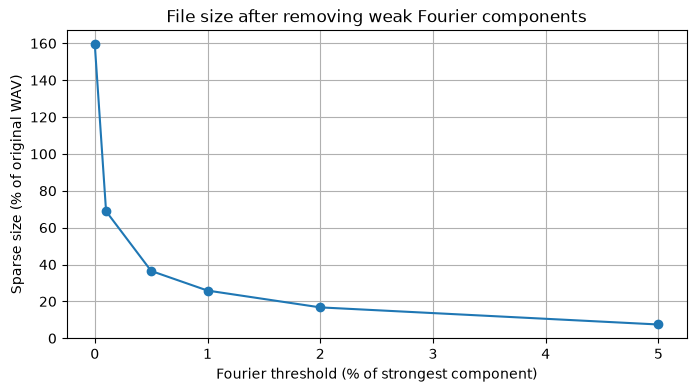

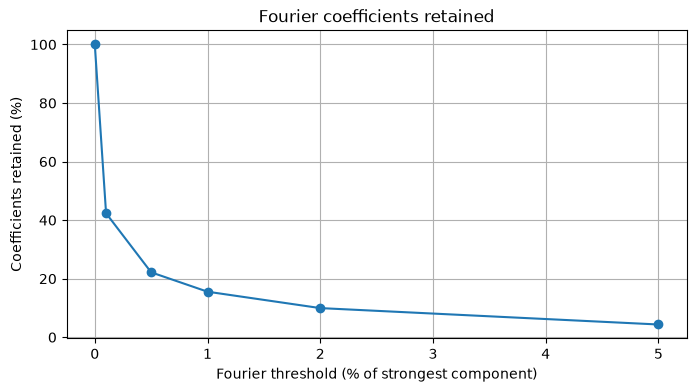

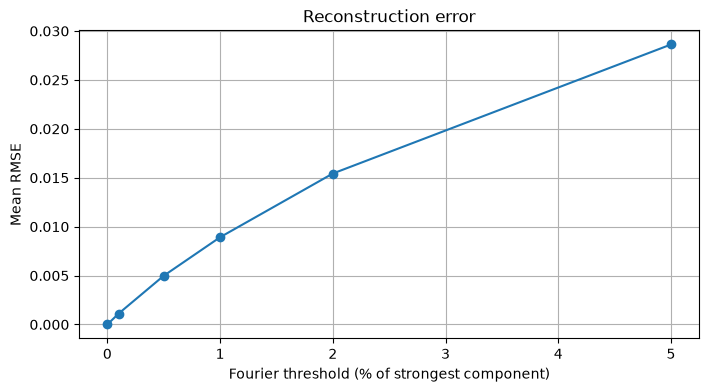

In [32]:
summary = []

for threshold in FOURIER_THRESHOLDS:
    r = fourier_results[threshold]

    kept_percent = (
        100 * r["kept_coefficients"] / r["total_coefficients"]
    )

    size_percent = (
        100 * r["sparse_bytes"] / r["original_bytes"]
    )

    reduction_percent = 100 - size_percent
    mean_rmse = float(np.mean(r["rmse"]))

    summary.append(
        (
            threshold,
            kept_percent,
            r["original_bytes"],
            r["sparse_bytes"],
            reduction_percent,
            mean_rmse,
        )
    )


# Print results
print(
    f"{'Threshold':>10} {'Kept %':>10} {'Original MiB':>14} "
    f"{'Sparse MiB':>12} {'Reduction %':>12} {'Mean RMSE':>12}"
)
print("-" * 76)

for threshold, kept, original, sparse, reduction, mean_rmse in summary:
    print(
        f"{threshold:10.3%} "
        f"{kept:10.2f} "
        f"{original / 2**20:14.2f} "
        f"{sparse / 2**20:12.2f} "
        f"{reduction:12.2f} "
        f"{mean_rmse:12.6f}"
    )


# Prepare plotting data
threshold_percent = [row[0] * 100 for row in summary]
kept_percent = [row[1] for row in summary]
size_percent = [100 - row[4] for row in summary]
mean_rmse = [row[5] for row in summary]


# Plot 1: file size
plt.figure(figsize=(8, 4))
plt.plot(threshold_percent, size_percent, marker="o")
plt.xlabel("Fourier threshold (% of strongest component)")
plt.ylabel("Sparse size (% of original WAV)")
plt.title("File size after removing weak Fourier components")
plt.grid()
plt.show()


# Plot 2: coefficients retained
plt.figure(figsize=(8, 4))
plt.plot(threshold_percent, kept_percent, marker="o")
plt.xlabel("Fourier threshold (% of strongest component)")
plt.ylabel("Coefficients retained (%)")
plt.title("Fourier coefficients retained")
plt.grid()
plt.show()


# Plot 3: reconstruction error
plt.figure(figsize=(8, 4))
plt.plot(threshold_percent, mean_rmse, marker="o")
plt.xlabel("Fourier threshold (% of strongest component)")
plt.ylabel("Mean RMSE")
plt.title("Reconstruction error")
plt.grid()
plt.show()

In [40]:
from IPython.display import Audio, display

# Choose which files to listen to
FILE_INDICES = [0, 1, 2]

# Choose Fourier threshold
# 0.001 = 0.1%
# 0.005 = 0.5%
# 0.01  = 1%
# 0.02  = 2%
# 0.05  = 5%
LISTEN_THRESHOLD = 0.1

for file_index in FILE_INDICES:
    wav_path = wav_files[file_index]

    signal, sample_rate = sf.read(
        wav_path,
        dtype="float32",
        always_2d=False
    )

    # Apply Fourier pruning
    indices, values, spectrum_shape, keep_mask = prune_fourier_components(
        signal,
        LISTEN_THRESHOLD
    )

    # Reconstruct the sound
    reconstructed = reconstruct_from_sparse_fourier(
        indices,
        values,
        spectrum_shape,
        signal.shape[0]
    )

    # Calculate some information
    kept_percent = 100 * keep_mask.sum() / keep_mask.size
    error = rmse(signal, reconstructed)

    print("=" * 70)
    print(f"File: {wav_path.name}")
    print(f"Threshold: {LISTEN_THRESHOLD * 100:.1f}%")
    print(f"Coefficients kept: {kept_percent:.2f}%")
    print(f"RMSE: {error:.6f}")

    print("\nORIGINAL:")
    display(
        Audio(
            np.clip(signal, -1, 1),
            rate=sample_rate,
            normalize=False
        )
    )

    print("AFTER FOURIER PRUNING:")
    display(
        Audio(
            np.clip(reconstructed, -1, 1),
            rate=sample_rate,
            normalize=False
        )
    )

File: 101415-3-0-2.wav
Threshold: 10.0%
Coefficients kept: 0.85%
RMSE: 0.034901

ORIGINAL:


AFTER FOURIER PRUNING:


File: 101415-3-0-3.wav
Threshold: 10.0%
Coefficients kept: 0.83%
RMSE: 0.037163

ORIGINAL:


AFTER FOURIER PRUNING:


File: 101415-3-0-8.wav
Threshold: 10.0%
Coefficients kept: 0.95%
RMSE: 0.031631

ORIGINAL:


AFTER FOURIER PRUNING:


In [38]:
# Difference between original and reconstructed signal
difference = signal - reconstructed

print("REMOVED / LOST INFORMATION:")
display(
    Audio(
        np.clip(difference, -1, 1),
        rate=sample_rate,
        normalize=False
    )
)

REMOVED / LOST INFORMATION:


File: 101415-3-0-2.wav
Threshold: 1.0%
RMSE: 0.004411
Kept coefficients: 5.65%


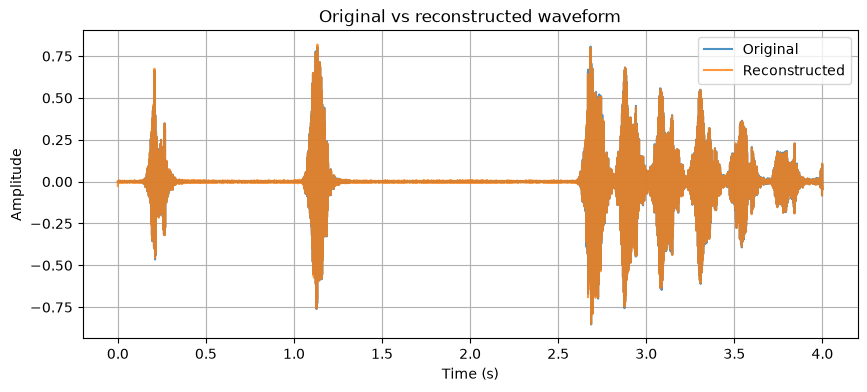

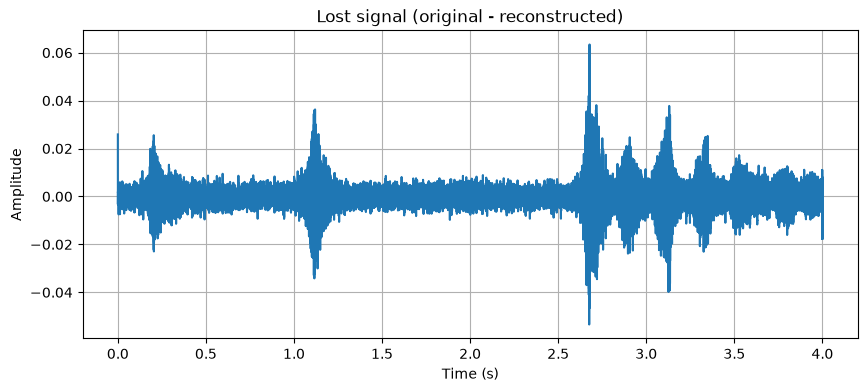

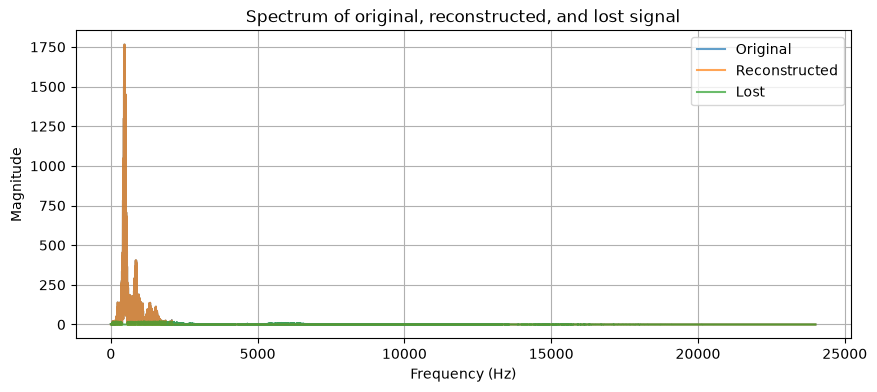

ORIGINAL AUDIO:


RECONSTRUCTED AUDIO:


LOST / REMOVED AUDIO:


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

# Choose one file and one threshold
FILE_INDEX = 0
VIS_THRESHOLD = 0.01   # 1%

wav_path = wav_files[FILE_INDEX]

signal, sample_rate = sf.read(
    wav_path,
    dtype="float32",
    always_2d=False
)

indices, values, spectrum_shape, keep_mask = prune_fourier_components(
    signal,
    VIS_THRESHOLD
)

reconstructed = reconstruct_from_sparse_fourier(
    indices,
    values,
    spectrum_shape,
    signal.shape[0]
)

# If stereo, convert to mono for plotting
if signal.ndim > 1:
    signal_plot = signal.mean(axis=1)
    reconstructed_plot = reconstructed.mean(axis=1)
else:
    signal_plot = signal
    reconstructed_plot = reconstructed

lost_signal = signal_plot - reconstructed_plot

time = np.arange(len(signal_plot)) / sample_rate

print(f"File: {wav_path.name}")
print(f"Threshold: {VIS_THRESHOLD*100:.1f}%")
print(f"RMSE: {rmse(signal_plot, reconstructed_plot):.6f}")
print(f"Kept coefficients: {100 * keep_mask.sum() / keep_mask.size:.2f}%")

# 1. Original and reconstructed waveform
plt.figure(figsize=(10, 4))
plt.plot(time, signal_plot, label="Original", alpha=0.8)
plt.plot(time, reconstructed_plot, label="Reconstructed", alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original vs reconstructed waveform")
plt.legend()
plt.grid()
plt.show()

# 2. Lost signal (difference)
plt.figure(figsize=(10, 4))
plt.plot(time, lost_signal)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Lost signal (original - reconstructed)")
plt.grid()
plt.show()

# 3. Frequency spectrum
orig_fft = np.abs(np.fft.rfft(signal_plot))
recon_fft = np.abs(np.fft.rfft(reconstructed_plot))
lost_fft = np.abs(np.fft.rfft(lost_signal))
freqs = np.fft.rfftfreq(len(signal_plot), d=1/sample_rate)

plt.figure(figsize=(10, 4))
plt.plot(freqs, orig_fft, label="Original", alpha=0.7)
plt.plot(freqs, recon_fft, label="Reconstructed", alpha=0.7)
plt.plot(freqs, lost_fft, label="Lost", alpha=0.7)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Spectrum of original, reconstructed, and lost signal")
plt.legend()
plt.grid()
plt.show()

print("ORIGINAL AUDIO:")
display(Audio(signal_plot, rate=sample_rate, normalize=False))

print("RECONSTRUCTED AUDIO:")
display(Audio(reconstructed_plot, rate=sample_rate, normalize=False))

print("LOST / REMOVED AUDIO:")
display(Audio(lost_signal, rate=sample_rate, normalize=False))

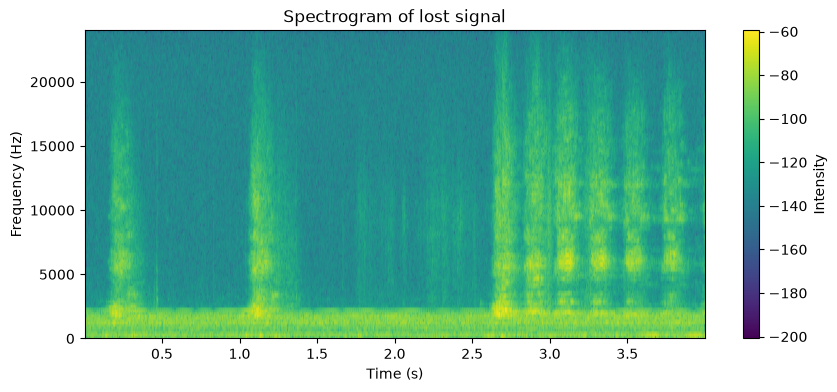

In [43]:
plt.figure(figsize=(10, 4))
plt.specgram(lost_signal, Fs=sample_rate)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of lost signal")
plt.colorbar(label="Intensity")
plt.show()